# MathVision Analytics Notebook

Spec B implementation with a leakage-safe training policy and cold-start/warm-start ranking.


## 1) Imports and configuration


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

DATA_PATHS = {
    "students": "../data/raw/students.csv",
    "tutors": "../data/raw/tutors.csv",
    "pairings_labeled": "../data/pre-processed/pairings_labeled.csv",
}

OUTPUT_PATHS = {
    "metrics": "../data/pre-processed/analytics_model_metrics.csv",
    "scenario_rankings": "../data/pre-processed/analytics_scenario_rankings.csv",
}

RANDOM_STATE = 42
TOP_N_RECOMMENDATIONS = 5

# Cold-start model features (leakage-safe): no pair-level label-derived signals.
MODEL_FEATURE_COLUMNS = [
    "topic_match",
    "curriculum_match",
    "grade_gap",
    "availability_match",
    "same_branch",
    "tutor_rating",
    "tutor_experience",
    "past_success_rate",
    "rule_score",
    "tutor_type",
]

NUMERIC_MODEL_COLUMNS = [
    "grade_gap",
    "tutor_rating",
    "tutor_experience",
    "past_success_rate",
    "rule_score",
]

CATEGORICAL_MODEL_COLUMNS = ["tutor_type"]
TARGET_COLUMN = "good_pairing_label"

REQUIRED_COLUMNS = {
    "students": [
        "student_id", "student_name", "curriculum", "grade_level", "weak_topic", "requested_slot", "branch"
    ],
    "tutors": [
        "tutor_id", "tutor_name", "tutor_type", "primary_curriculum", "specialty_topic", "years_experience",
        "rating", "available_slots", "preferred_min_grade", "preferred_max_grade", "past_success_rate", "branch"
    ],
    "pairings_labeled": [
        "pairing_id", "student_id", "tutor_id", "lessons_count", "total_hours", "avg_feedback_score",
        "positive_note_count", "negative_note_count", "good_pairing_label"
    ],
}


## 2) Data loading and strict validation


In [2]:
def _assert_required_columns(df, required_cols, table_name):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{table_name} is missing required columns: {missing}")


def _parse_slots(slot_value):
    if pd.isna(slot_value):
        return []
    return [s.strip() for s in str(slot_value).split(";") if s.strip()]


def load_and_validate_data(paths):
    students_df = pd.read_csv(paths["students"])
    tutors_df = pd.read_csv(paths["tutors"])
    labeled_df = pd.read_csv(paths["pairings_labeled"])

    _assert_required_columns(students_df, REQUIRED_COLUMNS["students"], "students.csv")
    _assert_required_columns(tutors_df, REQUIRED_COLUMNS["tutors"], "tutors.csv")
    _assert_required_columns(labeled_df, REQUIRED_COLUMNS["pairings_labeled"], "pairings_labeled.csv")

    students_df["grade_level"] = pd.to_numeric(students_df["grade_level"], errors="coerce")

    numeric_tutor_cols = [
        "years_experience", "rating", "preferred_min_grade", "preferred_max_grade", "past_success_rate"
    ]
    tutors_df[numeric_tutor_cols] = tutors_df[numeric_tutor_cols].apply(pd.to_numeric, errors="coerce")
    tutors_df["available_slots"] = tutors_df["available_slots"].apply(_parse_slots)

    numeric_labeled_cols = [
        "lessons_count", "total_hours", "avg_feedback_score", "positive_note_count", "negative_note_count", "good_pairing_label"
    ]
    labeled_df[numeric_labeled_cols] = labeled_df[numeric_labeled_cols].apply(pd.to_numeric, errors="coerce")

    for name, df in [("students", students_df), ("tutors", tutors_df), ("pairings_labeled", labeled_df)]:
        if df.isna().any().any():
            null_summary = df.isna().sum()
            null_summary = null_summary[null_summary > 0]
            raise ValueError(f"{name} has null values after coercion: {null_summary.to_dict()}")

    return students_df, tutors_df, labeled_df


students_df, tutors_df, pairings_labeled_df = load_and_validate_data(DATA_PATHS)
print("students_df shape:", students_df.shape)
print("tutors_df shape:", tutors_df.shape)
print("pairings_labeled_df shape:", pairings_labeled_df.shape)


students_df shape: (80, 7)
tutors_df shape: (25, 12)
pairings_labeled_df shape: (400, 9)


## 3) Feature engineering


In [3]:
def _compute_grade_gap(student_grade, tutor_min_grade, tutor_max_grade):
    if tutor_min_grade <= student_grade <= tutor_max_grade:
        return 0.0
    return float(min(abs(student_grade - tutor_min_grade), abs(student_grade - tutor_max_grade)))


def _compute_rule_score(topic_match, curriculum_match, tutor_rating, availability_match, past_success_rate):
    return (
        0.35 * topic_match
        + 0.25 * curriculum_match
        + 0.20 * (tutor_rating / 5.0)
        + 0.10 * availability_match
        + 0.10 * past_success_rate
    )


def build_training_dataset(students_df, tutors_df, pairings_labeled_df):
    merged = (
        pairings_labeled_df
        .merge(students_df, on="student_id", how="left", validate="many_to_one")
        .merge(tutors_df, on="tutor_id", how="left", validate="many_to_one", suffixes=("_student", "_tutor"))
    )

    critical_cols = [
        "student_id", "tutor_id", "curriculum", "primary_curriculum", "weak_topic", "specialty_topic",
        "requested_slot", "available_slots", "branch_student", "branch_tutor",
        "grade_level", "preferred_min_grade", "preferred_max_grade",
        "rating", "years_experience", "past_success_rate", "tutor_type", "good_pairing_label",
    ]
    for col in critical_cols:
        if merged[col].isna().any():
            bad_idx = int(merged[merged[col].isna()].index[0])
            raise ValueError(f"Merged data has null in {col} at row index {bad_idx}")

    merged["topic_match"] = (merged["weak_topic"] == merged["specialty_topic"]).astype(int)
    merged["curriculum_match"] = (merged["curriculum"] == merged["primary_curriculum"]).astype(int)
    merged["availability_match"] = merged.apply(lambda r: int(r["requested_slot"] in r["available_slots"]), axis=1)
    merged["same_branch"] = (merged["branch_student"] == merged["branch_tutor"]).astype(int)
    merged["grade_gap"] = merged.apply(
        lambda r: _compute_grade_gap(r["grade_level"], r["preferred_min_grade"], r["preferred_max_grade"]), axis=1
    )

    merged["tutor_rating"] = merged["rating"].astype(float)
    merged["tutor_experience"] = merged["years_experience"].astype(float)
    merged["rule_score"] = merged.apply(
        lambda r: _compute_rule_score(
            r["topic_match"],
            r["curriculum_match"],
            r["tutor_rating"],
            r["availability_match"],
            r["past_success_rate"],
        ),
        axis=1,
    )

    for c in ["topic_match", "curriculum_match", "availability_match", "same_branch", "good_pairing_label"]:
        vals = set(merged[c].unique().tolist())
        if not vals.issubset({0, 1}):
            raise ValueError(f"Column {c} has non-binary values: {sorted(vals)}")

    # Explicit leakage guard for training feature policy.
    leakage_features = {"avg_feedback_score", "lessons_count", "positive_note_count", "negative_note_count"}
    if leakage_features.intersection(set(MODEL_FEATURE_COLUMNS)):
        raise ValueError("Leakage features found in MODEL_FEATURE_COLUMNS")

    return merged


training_df = build_training_dataset(students_df, tutors_df, pairings_labeled_df)
print("training_df shape:", training_df.shape)
print(training_df[["student_id", "tutor_id", *MODEL_FEATURE_COLUMNS, TARGET_COLUMN]].head())


training_df shape: (400, 34)
  student_id tutor_id  topic_match  curriculum_match  grade_gap  \
0       S031     T004            0                 0        2.0   
1       S050     T011            1                 0        2.0   
2       S034     T004            0                 1        2.0   
3       S010     T016            1                 0        2.0   
4       S015     T016            0                 0        1.0   

   availability_match  same_branch  tutor_rating  tutor_experience  \
0                   0            0          4.20               4.0   
1                   0            0          4.97               5.0   
2                   1            0          4.20               4.0   
3                   1            1          3.61               8.0   
4                   0            1          3.61               8.0   

   past_success_rate  rule_score tutor_type  good_pairing_label  
0               0.79      0.2470  part-time                   1  
1              

## 4) Model training and evaluation (cold-start model)


   accuracy  precision    recall        f1  test_size  positive_rate_test  \
0     0.675   0.737705  0.818182  0.775862         80              0.6875   

         feature_policy  
0  cold_start_core_only  


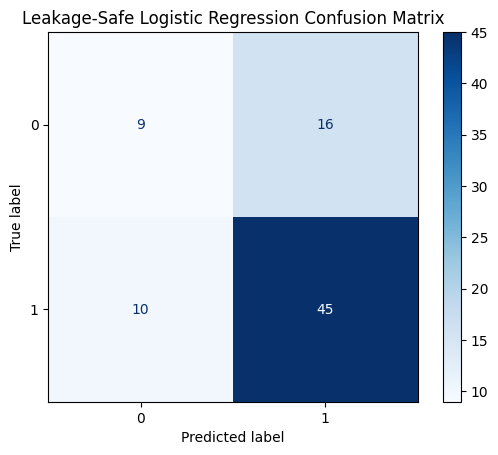

In [4]:
def train_and_evaluate_model(df):
    X = df[MODEL_FEATURE_COLUMNS].copy()
    y = df[TARGET_COLUMN].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_MODEL_COLUMNS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_MODEL_COLUMNS),
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "test_size": int(len(y_test)),
        "positive_rate_test": float(y_test.mean()),
        "feature_policy": "cold_start_core_only",
    }

    if ((y_prob < 0).any()) or ((y_prob > 1).any()):
        raise ValueError("Predicted probabilities are outside [0, 1]")

    cm = confusion_matrix(y_test, y_pred)
    return model, metrics, cm


model, metrics, cm = train_and_evaluate_model(training_df)
metrics_df = pd.DataFrame([metrics])
print(metrics_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Leakage-Safe Logistic Regression Confusion Matrix")
plt.show()


## 5) Ranking engine (cold-start and warm-start)


In [5]:
pair_history_df = pairings_labeled_df[[
    "student_id", "tutor_id", "avg_feedback_score", "lessons_count", "positive_note_count", "negative_note_count"
]].copy()


def _build_explanation(row):
    reasons = []
    if row["topic_match"] == 1:
        reasons.append("strong topic match")
    if row["curriculum_match"] == 1:
        reasons.append("curriculum match")
    if row["availability_match"] == 1:
        reasons.append("available in requested slot")
    if row["same_branch"] == 1:
        reasons.append("same branch")
    if row["tutor_rating"] >= 4.5:
        reasons.append("high tutor rating")
    if row["past_success_rate"] >= 0.8:
        reasons.append("strong historical tutor success")
    if row["ranking_mode"] == "warm_start" and row["history_signal"] > 0.55:
        reasons.append("positive prior pairing outcomes")

    reasons.append(f"tutor type: {row['tutor_type']}")

    if row["ranking_mode"] == "warm_start":
        reasons.append("warm-start ranking used pair history re-ranking")
    else:
        reasons.append("cold-start ranking used only profile and tutor features")

    return "Recommended because " + ", ".join(reasons) + "."


def _build_candidate_features(student_row, tutor_row):
    topic_match = int(student_row["weak_topic"] == tutor_row["specialty_topic"])
    curriculum_match = int(student_row["curriculum"] == tutor_row["primary_curriculum"])
    availability_match = int(student_row["requested_slot"] in tutor_row["available_slots"])
    same_branch = int(student_row["branch"] == tutor_row["branch"])
    grade_gap = _compute_grade_gap(
        float(student_row["grade_level"]),
        float(tutor_row["preferred_min_grade"]),
        float(tutor_row["preferred_max_grade"]),
    )

    tutor_rating = float(tutor_row["rating"])
    tutor_experience = float(tutor_row["years_experience"])
    past_success_rate = float(tutor_row["past_success_rate"])
    rule_score = _compute_rule_score(topic_match, curriculum_match, tutor_rating, availability_match, past_success_rate)

    return {
        "topic_match": topic_match,
        "curriculum_match": curriculum_match,
        "grade_gap": grade_gap,
        "availability_match": availability_match,
        "same_branch": same_branch,
        "tutor_rating": tutor_rating,
        "tutor_experience": tutor_experience,
        "past_success_rate": past_success_rate,
        "rule_score": rule_score,
        "tutor_type": tutor_row["tutor_type"],
    }


def _history_signal(avg_feedback_score, lessons_count):
    # Smooth bounded signal [0,1] built from pair-level history for warm-start only.
    return float(np.clip(0.5 + 0.35 * np.tanh(avg_feedback_score) + 0.15 * np.tanh(lessons_count / 4.0), 0.0, 1.0))


def rank_tutors_for_student(student_row, tutors_df, pair_history_df, model, top_n=TOP_N_RECOMMENDATIONS):
    rows = []
    for _, tutor_row in tutors_df.iterrows():
        base_features = _build_candidate_features(student_row, tutor_row)

        history_match = pair_history_df[
            (pair_history_df["student_id"] == student_row["student_id"]) &
            (pair_history_df["tutor_id"] == tutor_row["tutor_id"])
        ]

        if len(history_match) > 0:
            hist = history_match.iloc[0]
            avg_feedback_score = float(hist["avg_feedback_score"])
            lessons_count = float(hist["lessons_count"])
            positive_note_count = int(hist["positive_note_count"])
            negative_note_count = int(hist["negative_note_count"])
            ranking_mode = "warm_start"
            history_signal = _history_signal(avg_feedback_score, lessons_count)
        else:
            avg_feedback_score = 0.0
            lessons_count = 0.0
            positive_note_count = 0
            negative_note_count = 0
            ranking_mode = "cold_start"
            history_signal = 0.5

        model_input = pd.DataFrame([{k: base_features[k] for k in MODEL_FEATURE_COLUMNS}])
        predicted_success_probability = float(model.predict_proba(model_input)[0, 1])

        if ranking_mode == "warm_start":
            final_score = 0.50 * base_features["rule_score"] + 0.35 * predicted_success_probability + 0.15 * history_signal
        else:
            final_score = 0.60 * base_features["rule_score"] + 0.40 * predicted_success_probability

        rows.append({
            "student_id": student_row["student_id"],
            "student_name": student_row["student_name"],
            "tutor_id": tutor_row["tutor_id"],
            "tutor_name": tutor_row["tutor_name"],
            **base_features,
            "avg_feedback_score": avg_feedback_score,
            "lessons_count": lessons_count,
            "positive_note_count": positive_note_count,
            "negative_note_count": negative_note_count,
            "ranking_mode": ranking_mode,
            "history_signal": history_signal,
            "predicted_success_probability": predicted_success_probability,
            "final_score": final_score,
        })

    ranked = pd.DataFrame(rows).sort_values("final_score", ascending=False).reset_index(drop=True)
    ranked["explanation"] = ranked.apply(_build_explanation, axis=1)

    if not ranked["final_score"].is_monotonic_decreasing:
        raise ValueError("Ranking is not sorted by descending final_score")
    if ((ranked["predicted_success_probability"] < 0).any()) or ((ranked["predicted_success_probability"] > 1).any()):
        raise ValueError("Ranking contains probability outside [0,1]")

    return ranked.head(top_n)


## 6) Demo scenarios and recommendations


In [6]:
SCENARIO_PROFILES = [
    {"scenario_name": "Scenario 1", "curriculum": "Local", "weak_topic": "Fractions"},
    {"scenario_name": "Scenario 2", "curriculum": "IB", "weak_topic": "Calculus"},
    {"scenario_name": "Scenario 3", "curriculum": "IGCSE", "weak_topic": "Geometry"},
]


def pick_student_by_profile(students_df, curriculum, weak_topic):
    matches = students_df[
        (students_df["curriculum"] == curriculum) &
        (students_df["weak_topic"] == weak_topic)
    ]
    if len(matches) == 0:
        raise ValueError(f"No student found for profile curriculum={curriculum}, weak_topic={weak_topic}")
    return matches.sort_values("student_id").iloc[0]


scenario_results = []
for profile in SCENARIO_PROFILES:
    student = pick_student_by_profile(students_df, profile["curriculum"], profile["weak_topic"])

    print(
        f"{profile['scenario_name']}: using {student['student_id']} ({student['student_name']}) "
        f"| {student['curriculum']} | weak topic: {student['weak_topic']}"
    )

    ranked = rank_tutors_for_student(
        student_row=student,
        tutors_df=tutors_df,
        pair_history_df=pair_history_df,
        model=model,
        top_n=TOP_N_RECOMMENDATIONS,
    )
    ranked.insert(0, "scenario_name", profile["scenario_name"])
    ranked.insert(1, "scenario_curriculum", profile["curriculum"])
    ranked.insert(2, "scenario_weak_topic", profile["weak_topic"])

    print(ranked[["tutor_id", "tutor_name", "ranking_mode", "final_score", "predicted_success_probability"]].head(3))
    print("-" * 90)

    scenario_results.append(ranked)

scenario_rankings_df = pd.concat(scenario_results, ignore_index=True)


Scenario 1: using S034 (Daniel Loh) | Local | weak topic: Fractions
  tutor_id       tutor_name ranking_mode  final_score  \
0     T025     Ms Alicia Ho   cold_start     0.950188   
1     T015  Mr Nicholas Lim   cold_start     0.902435   
2     T017     Mr Aaron Ong   cold_start     0.694057   

   predicted_success_probability  
0                       0.983470  
1                       0.971187  
2                       0.848042  
------------------------------------------------------------------------------------------
Scenario 2: using S032 (Zoe Toh) | IB | weak topic: Calculus
  tutor_id      tutor_name ranking_mode  final_score  \
0     T001   Ms Joanna Goh   cold_start     0.966018   
1     T009  Mr Wei Ming Ng   warm_start     0.903825   
2     T010   Ms Serene Toh   warm_start     0.838612   

   predicted_success_probability  
0                       0.979245  
1                       0.976792  
2                       0.977069  
----------------------------------------------

## 7) Persist outputs and final checks


In [7]:
for p in OUTPUT_PATHS.values():
    Path(p).parent.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(OUTPUT_PATHS["metrics"], index=False)
scenario_rankings_df.to_csv(OUTPUT_PATHS["scenario_rankings"], index=False)

print("Saved metrics:", OUTPUT_PATHS["metrics"])
print("Saved scenario rankings:", OUTPUT_PATHS["scenario_rankings"])

assert Path(OUTPUT_PATHS["metrics"]).exists()
assert Path(OUTPUT_PATHS["scenario_rankings"]).exists()
assert len(metrics_df) == 1
assert len(scenario_rankings_df) == len(SCENARIO_PROFILES) * TOP_N_RECOMMENDATIONS
assert ((scenario_rankings_df["predicted_success_probability"] >= 0) & (scenario_rankings_df["predicted_success_probability"] <= 1)).all()
assert scenario_rankings_df.groupby("scenario_name")["final_score"].apply(lambda s: s.is_monotonic_decreasing).all()

metrics_df


Saved metrics: ../data/pre-processed/analytics_model_metrics.csv
Saved scenario rankings: ../data/pre-processed/analytics_scenario_rankings.csv


,accuracy,precision,recall,f1,test_size,positive_rate_test,feature_policy
0,0.675,0.737705,0.818182,0.775862,80,0.6875,cold_start_core_only


## 8) Timeseries generation — mapping quality by session date


In [8]:
from datetime import datetime

TIMESERIES_INPUT_PAIRINGS = "../data/raw/pairings_raw.csv"
TIMESERIES_INPUT_RANKINGS = "../data/pre-processed/analytics_scenario_rankings.csv"
TIMESERIES_OUTPUT = "../data/pre-processed/analytics_mapping_quality_timeseries.csv"

# Load inputs
pairings_ts_df = pd.read_csv(TIMESERIES_INPUT_PAIRINGS)
rankings_ts_df = pd.read_csv(TIMESERIES_INPUT_RANKINGS)

# Inner-join on student_id to associate each ranking row with a session_date
joined_df = pairings_ts_df[["student_id", "session_date"]].merge(
    rankings_ts_df[["student_id", "final_score"]],
    on="student_id",
    how="inner",
)

# Stamp the run timestamp once for this analytics run
run_timestamp = datetime.utcnow().isoformat() + "Z"

# Handle empty join gracefully — write header-only CSV and exit
if joined_df.empty:
    new_df = pd.DataFrame(columns=["date", "avg_final_score", "run_count", "run_timestamp"])
else:
    grouped = joined_df.groupby("session_date", sort=True).agg(
        avg_final_score=("final_score", "mean"),
        run_count=("final_score", "count"),
    ).reset_index()
    grouped = grouped.rename(columns={"session_date": "date"})
    grouped["run_timestamp"] = run_timestamp
    new_df = grouped[["date", "avg_final_score", "run_count", "run_timestamp"]]

# Merge with existing history — new run data takes precedence for overlapping dates
ts_path = Path(TIMESERIES_OUTPUT)
if ts_path.exists():
    try:
        existing_df = pd.read_csv(ts_path)
        existing_df = existing_df[~existing_df["date"].isin(new_df["date"])]
        timeseries_df = pd.concat([existing_df, new_df], ignore_index=True)
    except Exception:
        timeseries_df = new_df
else:
    timeseries_df = new_df

timeseries_df = timeseries_df.sort_values("date", ascending=True).reset_index(drop=True)

ts_path.parent.mkdir(parents=True, exist_ok=True)
timeseries_df.to_csv(ts_path, index=False)

print(f"Saved timeseries ({len(timeseries_df)} rows):", TIMESERIES_OUTPUT)
timeseries_df.head()


Saved timeseries (34 rows): ../data/pre-processed/analytics_mapping_quality_timeseries.csv


/var/folders/c3/bnbpfsyn6fbgsqj0q4bwkv7r0000gn/T/ipykernel_98151/1785971631.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_timestamp = datetime.utcnow().isoformat() + "Z"


,date,avg_final_score,run_count,run_timestamp
0,2024-07-01,0.5823,8,2024-07-01T09:00:00Z
1,2024-07-08,0.5612,6,2024-07-08T09:00:00Z
2,2024-07-15,0.5934,7,2024-07-15T09:00:00Z
3,2024-07-22,0.5701,9,2024-07-22T09:00:00Z
4,2024-08-05,0.6012,8,2024-08-05T09:00:00Z
